In [1]:
#import sys
#!{sys.executable} -m pip install xgboost

In [2]:
# imports and setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import re
import html
import unicodedata
import warnings
import time

from scipy.stats import spearmanr

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    average_precision_score,
    roc_auc_score
)
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    make_scorer,
    median_absolute_error,
    explained_variance_score,
)
from scipy.stats import spearmanr, pearsonr
from xgboost import XGBRegressor


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)


In [3]:
# find the raw json files

# path I use locally
json_dir = Path("../../data/raw")

# fallback when running in this notebook environment
if not json_dir.exists():
    json_dir = Path("/mnt/data")

# keep comment batches only; skip the tracker metadata file
json_files = sorted([
    p for p in json_dir.glob("*.json")
    if "scraped_videos_tracker" not in p.name
])

print("JSON directory:", json_dir.resolve())
print("Number of JSON files found:", len(json_files))
print([p.name for p in json_files[:5]])


JSON directory: C:\Users\Jamie\Documents\GitHub\summer26-viral-slang\Data\raw
Number of JSON files found: 75
['1STUD_batch_20260615_220936.json', '1STUD_batch_20260616_120929.json', '1STUD_batch_20260616_125913.json', '1STUD_batch_20260629_221901.json', 'AsmonTV_batch_20260608_205250.json']


In [4]:
# load the raw comment files

dfs = []

for json_file in json_files:
    temp = pd.read_json(json_file)

    # Example filename:
    #   MrBeastGaming_batch_20260608_205250.json
    # We extract:
    #   MrBeastGaming
    temp["channel_name"] = json_file.stem.split("_batch_")[0].replace("(1)", "")

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

# basic cleanup
df["published_at"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")
df["likes"] = pd.to_numeric(df["likes"], errors="coerce").fillna(0).clip(lower=0).astype(int)
df["text"] = df["text"].fillna("").astype(str)

# no timestamp means no week assignment
df = df.dropna(subset=["published_at"]).reset_index(drop=True)

# simple comment id after cleaning
df["comment_id"] = df.index

display(df.head())
display(df.info())

print("Raw comments:", len(df))
print("Unique videos:", df["video_id"].nunique())
print("Unique channels:", df["channel_name"].nunique())


,video_id,text,likes,published_at,channel_name,comment_id
0,BSv6hna2Ycs,3:22 zenin clan treatment,49,2026-06-15 11:44:27+00:00,1STUD,0
1,BSv6hna2Ycs,your goat stud i wacht you 4 years,29,2026-06-15 11:03:58+00:00,1STUD,1
2,BSv6hna2Ycs,I WATCHED YA FOR 2 YEARS!!!,6,2026-06-15 12:03:19+00:00,1STUD,2
3,BSv6hna2Ycs,2:21 Bro Noob Army Being Like God Slayer😂,3,2026-06-15 14:31:33+00:00,1STUD,3
4,BSv6hna2Ycs,Yo stud even though you probably not going to ...,3,2026-06-15 14:24:59+00:00,1STUD,4


<class 'pandas.DataFrame'>
RangeIndex: 1739328 entries, 0 to 1739327
Data columns (total 6 columns):
 #   Column        Dtype              
---  ------        -----              
 0   video_id      str                
 1   text          str                
 2   likes         int64              
 3   published_at  datetime64[us, UTC]
 4   channel_name  str                
 5   comment_id    int64              
dtypes: datetime64[us, UTC](1), int64(2), str(3)
memory usage: 79.6 MB


None

Raw comments: 1739328
Unique videos: 19517
Unique channels: 32


In [5]:
NUM_WEEKS = 40
FUTURE_WEEKS = 3

# assign each comment to a week

latest = df["published_at"].max()

# week_back = 0 means most recent week.
# week_back = 1 means one week before the most recent week.
df["week_back"] = ((latest - df["published_at"]).dt.days // 7).astype(int)

# keep the most recent 20 weeks
df = df[(df["week_back"] >= 0) & (df["week_back"] < NUM_WEEKS)].copy().reset_index(drop=True)

# reset ids after filtering
df["comment_id"] = df.index

# make time_id run from old -> new
df["time_id"] = df["week_back"].max() - df["week_back"]

display(df[["comment_id", "published_at", "week_back", "time_id", "text", "likes"]].head())

print("Comments in 20-week window:", len(df))
print("time_id range:", df["time_id"].min(), "to", df["time_id"].max())


,comment_id,published_at,week_back,time_id,text,likes
0,0,2026-06-15 11:44:27+00:00,2,37,3:22 zenin clan treatment,49
1,1,2026-06-15 11:03:58+00:00,2,37,your goat stud i wacht you 4 years,29
2,2,2026-06-15 12:03:19+00:00,2,37,I WATCHED YA FOR 2 YEARS!!!,6
3,3,2026-06-15 14:31:33+00:00,2,37,2:21 Bro Noob Army Being Like God Slayer😂,3
4,4,2026-06-15 14:24:59+00:00,2,37,Yo stud even though you probably not going to ...,3


Comments in 20-week window: 649855
time_id range: 0 to 39


In [6]:
# tokenize comments

TOKEN_RE = re.compile(
    r"""
    (?<![a-z0-9])
    \#?
    (?:
        [a-z]+(?:['’‘ʼ`´＇-][a-z]+)*[a-z0-9]*
        |
        [a-z]*\d+[a-z0-9]*
    )
    (?![a-z0-9])
    """,
    re.I | re.VERBOSE
)

URL_RE = re.compile(r"https?://\S+|www\.\S+")
TIME_RE = re.compile(r"\b\d{1,2}:\d{2}(?::\d{2})?\b")

APOSTROPHE_TRANSLATION = str.maketrans({
    "’": "'",
    "‘": "'",
    "ʼ": "'",
    "`": "'",
    "´": "'",
    "＇": "'"
})

def tokenize(text):
    """Basic tokenizer for comment text."""
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)
    text = text.translate(APOSTROPHE_TRANSLATION)
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = TIME_RE.sub(" ", text)

    tokens = [m.group(0).lstrip("#") for m in TOKEN_RE.finditer(text)]

    # Remove tokens that are only digits
    tokens = [t for t in tokens if not t.isdigit()]

    return tokens

df["tokens"] = df["text"].apply(tokenize)

display(df[["text", "tokens"]].sample(10, random_state=42))


,text,tokens
607813,I would have shat my pants if one of the offic...,"[i, would, have, shat, my, pants, if, one, of,..."
22695,The new early access character \ngot a awakening,"[the, new, early, access, character, got, a, a..."
576869,Deadpool having jack-o’s crouch is diabolical,"[deadpool, having, jack-o's, crouch, is, diabo..."
409707,22:23 о голубенький приветики.... Ло на голуб...,[]
166723,Only 3 comments holy,"[only, comments, holy]"
500919,The real horror wasn’t the animatronics — it w...,"[the, real, horror, wasn't, the, animatronics,..."
391561,14:54 Uhm well he may or may not have been eat...,"[uhm, well, he, may, or, may, not, have, been,..."
555810,Grałem w to w demo na ps5 i pod kontroler to n...,"[gra, em, w, to, w, demo, na, ps5, i, pod, kon..."
197034,Only dream is excited for his man hunt videos,"[only, dream, is, excited, for, his, man, hunt..."
282690,Te amo aquí los que apoyan a jenny devil,"[te, amo, aqu, los, que, apoyan, a, jenny, devil]"


In [7]:
# one word per comment

df_words = df.explode("tokens").rename(columns={"tokens": "word"})
df_words = df_words.dropna(subset=["word"])
df_words = df_words[df_words["word"].str.len() > 0].copy()

# count a word only once per comment
df_unique = df_words.drop_duplicates(["comment_id", "word", "time_id"])

display(df_words[["comment_id", "word", "likes", "time_id", "video_id"]].head())
display(df_unique[["comment_id", "word", "likes", "time_id", "video_id"]].head())

print("Word occurrences before de-duplication:", len(df_words))
print("Unique comment-word-week rows after de-duplication:", len(df_unique))


,comment_id,word,likes,time_id,video_id
0,0,zenin,49,37,BSv6hna2Ycs
0,0,clan,49,37,BSv6hna2Ycs
0,0,treatment,49,37,BSv6hna2Ycs
1,1,your,29,37,BSv6hna2Ycs
1,1,goat,29,37,BSv6hna2Ycs


,comment_id,word,likes,time_id,video_id
0,0,zenin,49,37,BSv6hna2Ycs
0,0,clan,49,37,BSv6hna2Ycs
0,0,treatment,49,37,BSv6hna2Ycs
1,1,your,29,37,BSv6hna2Ycs
1,1,goat,29,37,BSv6hna2Ycs


Word occurrences before de-duplication: 8702275
Unique comment-word-week rows after de-duplication: 7700334


In [8]:
# --------------------------------------------------
# Build stopword list
# --------------------------------------------------

stopwords = set("""
a about above after again against all am an and any are as at be because been before being below between both but by
can cannot could did do does doing down during each few for from further had has have having he her here hers herself
him himself his how i if in into is it its itself just me more most my myself no nor not of off on once only or other
our ours ourselves out over own same she should so some such than that the their theirs them themselves then there
these they this those through to too under until up very was we were what when where which while who whom why will
with you your yours yourself yourselves
""".split())

stopwords |= {
    "i'm","it's","that's","don't","you're","he's","she's","we're","they're",
    "i've","you've","we've","they've","i'll","you'll","we'll","they'll",
    "isn't","aren't","wasn't","weren't","can't","couldn't","wouldn't",
    "shouldn't","won't","didn't","doesn't","haven't","hasn't","hadn't",
    "there's","what's","who's","where's","when's","why's","how's",
    "im","ive","dont","cant","wont","youre","thats","theres","whats",
    "hes","shes","were","theyre","ll","re","ve","ur","amp"
}

stopwords |= {
    "would","one","get","even","video","go","know","never","got","good",
    "make","made","see","think","really","still","also","much","going",
    "people","bro","man","guys","time","way","back","first","last",
    "like","game","person","now","years","guy","kid","thing","stuff",
    "day","watch","look","looks","say","said","right","actually"
}



In [9]:

# Build one-row-per-word feature table 

weeks = list(range(NUM_WEEKS))

feature_weeks = list(range(NUM_WEEKS - FUTURE_WEEKS))

future_weeks = list(range(NUM_WEEKS - FUTURE_WEEKS, NUM_WEEKS))

eps_count = 1.0
eps_rel = 1e-10


weekly_comments = (
    df.groupby("time_id")["comment_id"]
    .nunique()
    .reindex(weeks)
    .fillna(0)
)

weekly_likes = (
    df.groupby("time_id")["likes"]
    .sum()
    .reindex(weeks)
    .fillna(0)
)


# Helper to make word x week matrices
def word_week_matrix(values=None, aggfunc="size"):
    if aggfunc == "size":
        mat = (
            df_unique
            .groupby(["word", "time_id"])
            .size()
            .unstack("time_id")
        )
    else:
        mat = (
            df_unique
            .pivot_table(
                index="word",
                columns="time_id",
                values=values,
                aggfunc=aggfunc
            )
        )

    mat = mat.reindex(columns=weeks).fillna(0)
    return mat


# Raw word-week matrices
count_mat = word_week_matrix(aggfunc="size")
likes_mat = word_week_matrix(values="likes", aggfunc="sum")
avg_likes_mat = word_week_matrix(values="likes", aggfunc="mean")
n_videos_mat = word_week_matrix(values="video_id", aggfunc=pd.Series.nunique)
n_channels_mat = word_week_matrix(values="channel_name", aggfunc=pd.Series.nunique)

avg_likes_mat = avg_likes_mat.fillna(0)
n_videos_mat = n_videos_mat.fillna(0)
n_channels_mat = n_channels_mat.fillna(0)

# Relative frequency and relative likes
rel_freq_mat = count_mat.div(weekly_comments.replace(0, np.nan), axis=1).fillna(0)
rel_likes_mat = likes_mat.div(weekly_likes.replace(0, np.nan), axis=1).fillna(0)


# Filter words
before_words = len(count_mat)

valid_words = [
    w for w in count_mat.index
    if (w not in stopwords) and (len(w) >= 2 or w in {"w", "l"})
]

count_mat = count_mat.loc[valid_words]
likes_mat = likes_mat.loc[valid_words]
avg_likes_mat = avg_likes_mat.loc[valid_words]
n_videos_mat = n_videos_mat.loc[valid_words]
n_channels_mat = n_channels_mat.loc[valid_words]
rel_freq_mat = rel_freq_mat.loc[valid_words]
rel_likes_mat = rel_likes_mat.loc[valid_words]

# keep words that appear at least 5 times in at least one week
keep_words = count_mat.index[(count_mat.max(axis=1) >= 5)]

count_mat = count_mat.loc[keep_words]
likes_mat = likes_mat.loc[keep_words]
avg_likes_mat = avg_likes_mat.loc[keep_words]
n_videos_mat = n_videos_mat.loc[keep_words]
n_channels_mat = n_channels_mat.loc[keep_words]
rel_freq_mat = rel_freq_mat.loc[keep_words]
rel_likes_mat = rel_likes_mat.loc[keep_words]

print("Unique words before filtering:", before_words)
print("Unique words after filtering:", len(keep_words))


# Make one wide dataframe
wide_parts = []

for name, mat in {
    "count": count_mat,
    "likes": likes_mat,
    "avg_likes": avg_likes_mat,
    "n_videos": n_videos_mat,
    "n_channels": n_channels_mat,
    "rel_freq": rel_freq_mat,
    "rel_likes": rel_likes_mat,
}.items():
    temp = mat.copy()
    temp.columns = [f"week_{i}_{name}" for i in temp.columns]
    wide_parts.append(temp)

wide = pd.concat(wide_parts, axis=1).fillna(0)

print("wide shape:", wide.shape)


# Target y
# X uses feature_weeks
# y uses future_weeks
past_rel_cols = [f"week_{i}_rel_freq" for i in feature_weeks]
future_rel_cols = [f"week_{i}_rel_freq" for i in future_weeks]

past_avg = wide[past_rel_cols].mean(axis=1)
future_avg = wide[future_rel_cols].mean(axis=1)

y = np.log((future_avg + eps_rel) / (past_avg + eps_rel))


# Build X from feature_weeks only
features = {}

base_vars = [
    "count",
    "likes",
    "avg_likes",
    "n_videos",
    "n_channels",
    "rel_freq",
    "rel_likes",
]

# raw histories
for var in base_vars:
    for i in feature_weeks:
        features[f"week_{i}_{var}"] = wide[f"week_{i}_{var}"]

# log growth features
for var in ["count", "likes", "avg_likes", "n_videos", "n_channels"]:
    for i in feature_weeks[1:]:
        features[f"{var}_log_growth_{i}_{i-1}"] = np.log(
            (wide[f"week_{i}_{var}"] + eps_count)
            / (wide[f"week_{i-1}_{var}"] + eps_count)
        )

for var in ["rel_freq", "rel_likes"]:
    for i in feature_weeks[1:]:
        features[f"{var}_log_growth_{i}_{i-1}"] = np.log(
            (wide[f"week_{i}_{var}"] + eps_rel)
            / (wide[f"week_{i-1}_{var}"] + eps_rel)
        )

# likes per comment
for i in feature_weeks:
    features[f"likes_per_comment_{i}"] = (
        wide[f"week_{i}_likes"] / (wide[f"week_{i}_count"] + eps_count)
    )

# summary features
count_cols = [f"week_{i}_count" for i in feature_weeks]
rel_cols = [f"week_{i}_rel_freq" for i in feature_weeks]
like_cols = [f"week_{i}_likes" for i in feature_weeks]
video_cols = [f"week_{i}_n_videos" for i in feature_weeks]
channel_cols = [f"week_{i}_n_channels" for i in feature_weeks]

features["weeks_nonzero"] = (wide[count_cols] > 0).sum(axis=1)

features["count_mean"] = wide[count_cols].mean(axis=1)
features["count_std"] = wide[count_cols].std(axis=1)
features["count_max"] = wide[count_cols].max(axis=1)

features["rel_freq_mean"] = wide[rel_cols].mean(axis=1)
features["rel_freq_std"] = wide[rel_cols].std(axis=1)
features["rel_freq_max"] = wide[rel_cols].max(axis=1)

features["likes_mean"] = wide[like_cols].mean(axis=1)
features["likes_std"] = wide[like_cols].std(axis=1)
features["likes_max"] = wide[like_cols].max(axis=1)

features["n_videos_mean"] = wide[video_cols].mean(axis=1)
features["n_videos_max"] = wide[video_cols].max(axis=1)

# recent momentum
recent_weeks = feature_weeks[-3:]
prev_weeks = feature_weeks[-6:-3]

features["rel_freq_recent3_mean"] = wide[[f"week_{i}_rel_freq" for i in recent_weeks]].mean(axis=1)
features["rel_freq_prev3_mean"] = wide[[f"week_{i}_rel_freq" for i in prev_weeks]].mean(axis=1)
features["rel_freq_momentum_3w"] = (
    features["rel_freq_recent3_mean"] - features["rel_freq_prev3_mean"]
)

features["likes_recent3_mean"] = wide[[f"week_{i}_likes" for i in recent_weeks]].mean(axis=1)
features["likes_prev3_mean"] = wide[[f"week_{i}_likes" for i in prev_weeks]].mean(axis=1)
features["likes_momentum_3w"] = (
    features["likes_recent3_mean"] - features["likes_prev3_mean"]
)

# slopes
week_nums = np.array(feature_weeks)

def slope(row):
    return np.polyfit(week_nums, row.values, 1)[0]

features["rel_freq_slope"] = wide[rel_cols].apply(slope, axis=1)
features["count_slope"] = wide[count_cols].apply(slope, axis=1)
features["likes_slope"] = wide[like_cols].apply(slope, axis=1)

X = pd.DataFrame(features, index=wide.index)
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y summary:")
print(y.describe())

Unique words before filtering: 141922
Unique words after filtering: 13198
wide shape: (13198, 280)
X shape: (13198, 569)
y shape: (13198,)
y summary:
count    13198.000000
mean        -3.291936
std          5.351920
min        -16.211191
25%         -2.436663
50%         -0.883181
75%         -0.123020
max         16.050188
dtype: float64


In [10]:
X

,week_0_count,week_1_count,week_2_count,week_3_count,week_4_count,week_5_count,week_6_count,week_7_count,week_8_count,week_9_count,week_10_count,week_11_count,week_12_count,week_13_count,week_14_count,week_15_count,week_16_count,week_17_count,week_18_count,week_19_count,week_20_count,week_21_count,week_22_count,week_23_count,week_24_count,week_25_count,week_26_count,week_27_count,week_28_count,week_29_count,week_30_count,week_31_count,week_32_count,week_33_count,week_34_count,week_35_count,week_36_count,week_0_likes,week_1_likes,week_2_likes,week_3_likes,week_4_likes,week_5_likes,week_6_likes,week_7_likes,week_8_likes,week_9_likes,week_10_likes,week_11_likes,week_12_likes,week_13_likes,week_14_likes,week_15_likes,week_16_likes,week_17_likes,week_18_likes,week_19_likes,week_20_likes,week_21_likes,week_22_likes,week_23_likes,week_24_likes,week_25_likes,week_26_likes,week_27_likes,week_28_likes,week_29_likes,week_30_likes,week_31_likes,week_32_likes,week_33_likes,week_34_likes,week_35_likes,week_36_likes,week_0_avg_likes,week_1_avg_likes,week_2_avg_likes,week_3_avg_likes,week_4_avg_likes,week_5_avg_likes,week_6_avg_likes,week_7_avg_likes,week_8_avg_likes,week_9_avg_likes,week_10_avg_likes,week_11_avg_likes,week_12_avg_likes,week_13_avg_likes,week_14_avg_likes,week_15_avg_likes,week_16_avg_likes,week_17_avg_likes,week_18_avg_likes,week_19_avg_likes,week_20_avg_likes,week_21_avg_likes,week_22_avg_likes,week_23_avg_likes,week_24_avg_likes,week_25_avg_likes,...,rel_freq_log_growth_31_30,rel_freq_log_growth_32_31,rel_freq_log_growth_33_32,rel_freq_log_growth_34_33,rel_freq_log_growth_35_34,rel_freq_log_growth_36_35,rel_likes_log_growth_1_0,rel_likes_log_growth_2_1,rel_likes_log_growth_3_2,rel_likes_log_growth_4_3,rel_likes_log_growth_5_4,rel_likes_log_growth_6_5,rel_likes_log_growth_7_6,rel_likes_log_growth_8_7,rel_likes_log_growth_9_8,rel_likes_log_growth_10_9,rel_likes_log_growth_11_10,rel_likes_log_growth_12_11,rel_likes_log_growth_13_12,rel_likes_log_growth_14_13,rel_likes_log_growth_15_14,rel_likes_log_growth_16_15,rel_likes_log_growth_17_16,rel_likes_log_growth_18_17,rel_likes_log_growth_19_18,rel_likes_log_growth_20_19,rel_likes_log_growth_21_20,rel_likes_log_growth_22_21,rel_likes_log_growth_23_22,rel_likes_log_growth_24_23,rel_likes_log_growth_25_24,rel_likes_log_growth_26_25,rel_likes_log_growth_27_26,rel_likes_log_growth_28_27,rel_likes_log_growth_29_28,rel_likes_log_growth_30_29,rel_likes_log_growth_31_30,rel_likes_log_growth_32_31,rel_likes_log_growth_33_32,rel_likes_log_growth_34_33,rel_likes_log_growth_35_34,rel_likes_log_growth_36_35,likes_per_comment_0,likes_per_comment_1,likes_per_comment_2,likes_per_comment_3,likes_per_comment_4,likes_per_comment_5,likes_per_comment_6,likes_per_comment_7,likes_per_comment_8,likes_per_comment_9,likes_per_comment_10,likes_per_comment_11,likes_per_comment_12,likes_per_comment_13,likes_per_comment_14,likes_per_comment_15,likes_per_comment_16,likes_per_comment_17,likes_per_comment_18,likes_per_comment_19,likes_per_comment_20,likes_per_comment_21,likes_per_comment_22,likes_per_comment_23,likes_per_comment_24,likes_per_comment_25,likes_per_comment_26,likes_per_comment_27,likes_per_comment_28,likes_per_comment_29,likes_per_comment_30,likes_per_comment_31,likes_per_comment_32,likes_per_comment_33,likes_per_comment_34,likes_per_comment_35,likes_per_comment_36,weeks_nonzero,count_mean,count_std,count_max,rel_freq_mean,rel_freq_std,rel_freq_max,likes_mean,likes_std,likes_max,n_videos_mean,n_videos_max,rel_freq_recent3_mean,rel_freq_prev3_mean,rel_freq_momentum_3w,likes_recent3_mean,likes_prev3_mean,likes_momentum_3w,rel_freq_slope,count_slope,likes_slope
word,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
100k,2.0,13.0,7.0,5.0,6.0,9.0,6.0,2.0,3.0,17.0,4.0,11.0,5.0,5.0,2.0,6.0,3.0,3.0,3.0,7.0,5.0,5.0,4.0,3.0,2.0,4.0,12.0,10.0,14.0,2.0,8.0,12.0,

In [11]:
currentweeks=range(9,37)

In [12]:
timeX = pd.DataFrame(index=pd.MultiIndex.from_product([currentweeks,keep_words]))

In [13]:
for i in range(0,10):
    for j in currentweeks:
        for var in base_vars:
            timeX.loc[j,f"week_{-i}_{var}"] = X[f"week_{j-i}_{var}"].values
            if j-i>0:
                timeX.loc[j,f"{var}_log_growth_{-i}_{-i-1}"] = X[f"{var}_log_growth_{j-i}_{j-i-1}"].values
        timeX.loc[j,f"likes_per_comment_{-i}"] = X[f"likes_per_comment_{j-i}"].values
count_cols = [f"week_{-i}_count" for i in range(0,10)]
rel_cols = [f"week_{-i}_rel_freq" for i in range(0,10)]
like_cols = [f"week_{-i}_likes" for i in range(0,10)]
video_cols = [f"week_{-i}_n_videos" for i in range(0,10)]
channel_cols = [f"week_{-i}_n_channels" for i in range(0,10)]

timeX["weeks_nonzero"] = (timeX[count_cols] > 0).sum(axis=1)

timeX["count_mean"] = timeX[count_cols].mean(axis=1)
timeX["count_std"] = timeX[count_cols].std(axis=1)
timeX["count_max"] = timeX[count_cols].max(axis=1)

timeX["rel_freq_mean"] = timeX[rel_cols].mean(axis=1)
timeX["rel_freq_std"] = timeX[rel_cols].std(axis=1)
timeX["rel_freq_max"] = timeX[rel_cols].max(axis=1)

timeX["likes_mean"] = timeX[like_cols].mean(axis=1)
timeX["likes_std"] = timeX[like_cols].std(axis=1)
timeX["likes_max"] = timeX[like_cols].max(axis=1)

timeX["n_videos_mean"] = timeX[video_cols].mean(axis=1)
timeX["n_videos_max"] = timeX[video_cols].max(axis=1)

# recent momentum
recent_weeks = range(-2,1)
prev_weeks = range(-5,-2)

timeX["rel_freq_recent3_mean"] = timeX[[f"week_{i}_rel_freq" for i in recent_weeks]].mean(axis=1)
timeX["rel_freq_prev3_mean"] = timeX[[f"week_{i}_rel_freq" for i in prev_weeks]].mean(axis=1)
timeX["rel_freq_momentum_3w"] = (
    timeX["rel_freq_recent3_mean"] - timeX["rel_freq_prev3_mean"]
)

timeX["likes_recent3_mean"] = timeX[[f"week_{i}_likes" for i in recent_weeks]].mean(axis=1)
timeX["likes_prev3_mean"] = timeX[[f"week_{i}_likes" for i in prev_weeks]].mean(axis=1)
timeX["likes_momentum_3w"] = (
    timeX["likes_recent3_mean"] - timeX["likes_prev3_mean"]
)

# slopes
week_nums = np.array(range(-9,1))

def slope(row):
    return np.polyfit(week_nums, row.values, 1)[0]

timeX["rel_freq_slope"] = timeX[rel_cols].apply(slope, axis=1)
timeX["count_slope"] = timeX[count_cols].apply(slope, axis=1)
timeX["likes_slope"] = timeX[like_cols].apply(slope, axis=1)

timeX = timeX.replace([np.inf, -np.inf], np.nan).fillna(0)

print("timeX shape:", timeX.shape)

timeX shape: (369544, 171)


In [14]:
timeX

week_0_count  count_log_growth_0_-1  week_0_likes  \
   word                                                          
9  100k              17.0               1.504077        2500.0   
   100x               1.0              -0.405465          38.0   
   1080p              3.0               0.287682           9.0   
   10k                9.0               1.203973        2850.0   
   10pm               1.0               0.693147           2.0   
...                   ...                    ...           ...   
36 zootopia           2.0               0.000000           8.0   
   zoro               1.0               0.000000           1.0   
   zuck               0.0               0.000000           0.0   
   zuko               0.0              -0.693147           0.0   
   zulu               0.0               0.000000           0.0   

             likes_log_growth_0_-1  week_0_avg_likes  \
   word                                                
9  100k                   4.566349        147.058824   
   100x                   3.663562         38.000000   
   1080p                  0.916291          3.000000   
   10k                    4.400077        316.666667   
   10pm                   1.098612          2.000000   
...                            ...               ...   
36 zootopia               1.504077          4.000000   
   zoro                   0.000000          1.000000   
   zuck                   0.000000          0.000000   
   zuko                  -0.693147          0.000000   
   zulu                   0.000000          0.000000   

             avg_likes_log_growth_0_-1  week_0_n_videos  \
   word                                                   
9  100k                       2.764017             10.0   
   100x                       3.663562              1.0   
   1080p                      0.470004              2.0   
   10k                        2.870631              6.0   
   10pm                       1.098612              1.0   
...                                ...              ...   
36 zootopia                   1.203973              1.0   
   zoro                       0.000000              1.0   
   zuck                       0.000000              0.0   
   zuko                      -0.693147              0.0   
   zulu                       0.000000              0.0   

             n_videos_log_growth_0_-1  week_0_n_channels  \
   word                                                    
9  100k                      1.011601                5.0   
   100x                     -0.405465                1.0   
   1080p                     0.000000                2.0   
   10k                       0.847298                5.0   
   10pm                      0.693147                1.0   
...                               ...                ...   
36 zootopia                 -0.405465                1.0   
   zoro                      0.000000                1.0   
   zuck                      0.000000                0.0   
   zuko                     -0.693147                0.0   
   zulu                      0.000000                0.0   

             n_channels_log_growth_0_-1  week_0_rel_freq  \
   word                                                    
9  100k                        0.405465         0.001293   
   100x                       -0.405465         0.000076   
   1080p                       0.000000         0.000228   
   10k                         0.693147         0.000685   
   10pm                        0.693147         0.000076   
...                                 ...              ...   
36 zootopia                    0.000000         0.000062   
   zoro                        0.000000         0.000031   
   zuck                        0.000000         0.000000   
   zuko                       -0.693147         0.000000   
   zulu                        0.000000         0.000000   

             rel_freq_log_growth_0_-1  week_0_rel_likes  \
   word                             

In [15]:
timey = pd.Series(index = timeX.index)

In [16]:
for i in currentweeks:
    # Target y
    # X uses feature_weeks
    # y uses future_weeks
    past_rel_cols = [f"week_{i}_rel_freq" for i in range(i-9,i+1)]
    future_rel_cols = [f"week_{i}_rel_freq" for i in range(i+1,i+4)]

    past_avg = wide[past_rel_cols].mean(axis=1)
    future_avg = wide[future_rel_cols].mean(axis=1)

    timey.loc[i] = np.log((future_avg + eps_rel) / (past_avg + eps_rel))

In [17]:
dropindices = timeX.loc[timeX[count_cols].max(axis=1)<5].index
for i in currentweeks:
    future_count_cols = [f"week_{i+j}_count" for j in range(1,4)]
    dropindices = dropindices.union(pd.MultiIndex.from_product([[i],wide.loc[wide[future_count_cols].max(axis=1)<5].index]))


In [18]:
timeX=timeX.drop(dropindices)

In [19]:
timey=timey.drop(dropindices)

In [20]:
timeX

week_0_count  count_log_growth_0_-1  week_0_likes  \
   word                                                         
9  100k             17.0               1.504077        2500.0   
   1080p             3.0               0.287682           9.0   
   10k               9.0               1.203973        2850.0   
   1k                4.0               0.223144        2084.0   
   1st              14.0               0.310155        3447.0   
...                  ...                    ...           ...   
36 zero             91.0               1.087801       27167.0   
   zombie           37.0               1.152680        2077.0   
   zombies          22.0               0.832909        1391.0   
   zone              7.0              -0.405465         275.0   
   zones             5.0               0.693147         199.0   

            likes_log_growth_0_-1  week_0_avg_likes  \
   word                                               
9  100k                  4.566349        147.058824   
   1080p                 0.916291          3.000000   
   10k                   4.400077        316.666667   
   1k                    2.400777        521.000000   
   1st                   1.696660        246.214286   
...                           ...               ...   
36 zero                  1.111728        298.538462   
   zombie                3.196510         56.135135   
   zombies               3.804510         63.227273   
   zone                 -2.365424         39.285714   
   zones                 1.078810         39.800000   

            avg_likes_log_growth_0_-1  week_0_n_videos  \
   word                                                  
9  100k                      2.764017             10.0   
   1080p                     0.470004              2.0   
   10k                       2.870631              6.0   
   1k                        2.104006              4.0   
   1st                       1.349811             14.0   
...                               ...              ...   
36 zero                      0.002134             48.0   
   zombie                    1.889438             18.0   
   zombies                   2.696091             12.0   
   zone                     -1.895329              7.0   
   zones                     0.167723              4.0   

            n_videos_log_growth_0_-1  week_0_n_channels  \
   word                                                   
9  100k                     1.011601                5.0   
   1080p                    0.000000                2.0   
   10k                      0.847298                5.0   
   1k                       0.223144                3.0   
   1st                      0.405465               10.0   
...                              ...                ...   
36 zero                     0.672944               12.0   
   zombie                   0.641854               10.0   
   zombies                  0.367725                7.0   
   zone                    -0.117783                4.0   
   zones                    0.510826                1.0   

            n_channels_log_growth_0_-1  week_0_rel_freq  \
   word                                                   
9  100k                       0.405465         0.001293   
   1080p                      0.000000         0.000228   
   10k                        0.693147         0.000685   
   1k                         0.000000         0.000304   
   1st                        0.606136         0.001065   
...                                ...              ...   
36 zero                       0.367725         0.002808   
   zombie                     0.606136         0.001142   
   zombies                    0.133531         0.000679   
   zone                      -0.336472         0.000216   
   zones                     -0.405465         0.000154   

            rel_freq_log_growth_0_-1  week_0_rel_likes  \
   word                                                  
9  100k                     1.831756       

In [29]:
kept_words = set([row[1] for row in timeX.index])

In [33]:
len(list(kept_words))

8173

In [57]:
# train-test split
import math
np.random.seed(247)
testwords = np.random.choice(list(kept_words),math.ceil(len(kept_words)*0.2),replace = False)
timeX_test_words = timeX.loc[timeX.index.map(lambda tuple: tuple[1] in testwords)].copy()
timeX_test_time = timeX.loc[(timeX.index.map(lambda tuple: tuple[1] not in testwords))&(timeX.index.map(lambda tuple: tuple[0] >= 32))].copy()
timeX_train = timeX.loc[(timeX.index.map(lambda tuple: tuple[1] not in testwords))&(timeX.index.map(lambda tuple: tuple[0] < 32))].copy()

In [58]:
#train-validation split
np.random.seed(247)
trainwords = kept_words.difference(set(testwords))
valwords = np.random.choice(list(trainwords),math.ceil(len(trainwords)*0.2),replace = False)
timeX_val_words = timeX_train.loc[timeX_train.index.map(lambda tuple: tuple[1] in valwords)].copy()
timeX_val_time = timeX_train.loc[(timeX_train.index.map(lambda tuple: tuple[1] not in valwords))
    &(timeX_train.index.map(lambda tuple: tuple[0] >= 27))].copy()
timeX_tt = timeX_train.loc[(timeX_train.index.map(lambda tuple: tuple[1] not in valwords))
    &(timeX_train.index.map(lambda tuple: tuple[0] < 27))].copy()

In [59]:
#another train-validation split for hyperparameter tuning
np.random.seed(247)
ttwords = trainwords.difference(set(valwords))
val2words = np.random.choice(list(ttwords),math.ceil(len(ttwords)*0.2),replace = False)
timeX_val2_words = timeX_tt.loc[timeX_tt.index.map(lambda tuple: tuple[1] in val2words)].copy()
timeX_val2_time = timeX_tt.loc[(timeX_tt.index.map(lambda tuple: tuple[1] not in val2words))
    &(timeX_tt.index.map(lambda tuple: tuple[0] >= 22))].copy()
timeX_tt2 = timeX_tt.loc[(timeX_tt.index.map(lambda tuple: tuple[1] not in val2words))
    &(timeX_tt.index.map(lambda tuple: tuple[0] < 22))].copy()

In [60]:
timey_class = timey.map(lambda y: 1 if y>1 else 0)

In [61]:
timey_test_words = timey_class.loc[timey.index.map(lambda tuple: tuple[1] in testwords)].copy()
timey_test_time = timey_class.loc[(timey.index.map(lambda tuple: tuple[1] not in testwords))&(timey.index.map(lambda tuple: tuple[0] >= 32))].copy()
timey_train = timey_class.loc[(timey.index.map(lambda tuple: tuple[1] not in testwords))&(timey.index.map(lambda tuple: tuple[0] < 32))].copy()

In [62]:
timey_val_words = timey_train.loc[timey_train.index.map(lambda tuple: tuple[1] in valwords)].copy()
timey_val_time = timey_train.loc[(timey_train.index.map(lambda tuple: tuple[1] not in valwords))
    &(timey_train.index.map(lambda tuple: tuple[0] >= 27))].copy()
timey_tt = timey_train.loc[(timey_train.index.map(lambda tuple: tuple[1] not in valwords))
    &(timey_train.index.map(lambda tuple: tuple[0] < 27))].copy()

In [64]:
timey_val2_words = timey_tt.loc[timey_tt.index.map(lambda tuple: tuple[1] in val2words)].copy()
timey_val2_time = timey_tt.loc[(timey_tt.index.map(lambda tuple: tuple[1] not in val2words))
    &(timey_tt.index.map(lambda tuple: tuple[0] >= 22))].copy()
timey_tt2 = timey_tt.loc[(timey_tt.index.map(lambda tuple: tuple[1] not in val2words))
    &(timey_tt.index.map(lambda tuple: tuple[0] < 22))].copy()

In [68]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix

In [71]:
for i in range(-10,10):
    ridge = make_pipeline(
            StandardScaler(),
            RidgeClassifier(alpha=10**i)
        )
    ridge.fit(timeX_tt2, timey_tt2)
    y_pred_time = ridge.predict(timeX_val2_time)
    y_pred_words = ridge.predict(timeX_val2_words)
    print("alpha = 10^"+str(i))
    print("New time confusion matrix")
    print(confusion_matrix(timey_val2_time,y_pred_time))
    print("New words confusion matrix")
    print(confusion_matrix(timey_val2_words,y_pred_words))

alpha = 10^-10
New time confusion matrix
[[12309     3]
 [  429     6]]
New words confusion matrix
[[10217     2]
 [  263     4]]
alpha = 10^-9
New time confusion matrix
[[12309     3]
 [  429     6]]
New words confusion matrix
[[10217     2]
 [  263     4]]
alpha = 10^-8
New time confusion matrix
[[12309     3]
 [  429     6]]
New words confusion matrix
[[10217     2]
 [  263     4]]
alpha = 10^-7
New time confusion matrix
[[12309     3]
 [  429     6]]
New words confusion matrix
[[10217     2]
 [  263     4]]
alpha = 10^-6
New time confusion matrix
[[12309     3]
 [  429     6]]
New words confusion matrix
[[10217     2]
 [  263     4]]
alpha = 10^-5
New time confusion matrix
[[12309     3]
 [  429     6]]
New words confusion matrix
[[10217     2]
 [  263     4]]
alpha = 10^-4
New time confusion matrix
[[12309     3]
 [  429     6]]
New words confusion matrix
[[10217     2]
 [  263     4]]
alpha = 10^-3
New time confusion matrix
[[12309     3]
 [  429     6]]
New words confusion matri

The value of alpha doesn't seem to make much difference until alpha is high. Lets just say alpha=1.

In [73]:
#this took about 30 minutes to run
precision_array_time = np.zeros((6,13,5))
precision_array_words = np.zeros((6,13,5))
recall_array_time = np.zeros((6,13,5))
recall_array_words = np.zeros((6,13,5))
for n_estimators in [100,200,300,400,500,600]:
    for max_depth in range(6,19):
        for min_samples_leaf in range(1,6):
            forest = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    random_state=42,
                    n_jobs=-1
                )
            forest.fit(timeX_tt2, timey_tt2)
            y_pred_time = forest.predict(timeX_val2_time)
            y_pred_words = forest.predict(timeX_val2_words)
            time_conf_mat = confusion_matrix(timey_val2_time,y_pred_time)
            words_conf_mat = confusion_matrix(timey_val2_words,y_pred_words)
            if time_conf_mat[1,1] !=0:
                precision_array_time[(n_estimators//100)-1,max_depth-6,min_samples_leaf-1] = time_conf_mat[1,1]/(time_conf_mat[1,1]+time_conf_mat[0,1])
                recall_array_time[(n_estimators//100)-1,max_depth-6,min_samples_leaf-1] = time_conf_mat[1,1]/(time_conf_mat[1,1]+time_conf_mat[1,0])
            if words_conf_mat[1,1] !=0:
                precision_array_words[(n_estimators//100)-1,max_depth-6,min_samples_leaf-1] = words_conf_mat[1,1]/(words_conf_mat[1,1]+words_conf_mat[0,1])
                recall_array_words[(n_estimators//100)-1,max_depth-6,min_samples_leaf-1] = words_conf_mat[1,1]/(words_conf_mat[1,1]+words_conf_mat[1,0])

In [77]:
print(precision_array_time)
print(precision_array_words)
print(recall_array_time)
print(recall_array_words)

[[[0.72151899 0.70930233 0.69512195 0.69135802 0.71764706]
  [0.7195122  0.68235294 0.68965517 0.69047619 0.69767442]
  [0.68965517 0.69230769 0.67391304 0.6875     0.69767442]
  [0.67777778 0.67032967 0.68421053 0.68817204 0.68817204]
  [0.67       0.65934066 0.67708333 0.69565217 0.68817204]
  [0.67346939 0.67741935 0.67       0.65957447 0.69072165]
  [0.67961165 0.65979381 0.66315789 0.67368421 0.67708333]
  [0.68       0.6875     0.67346939 0.64948454 0.69473684]
  [0.66666667 0.67346939 0.64485981 0.66666667 0.69791667]
  [0.64485981 0.66666667 0.66666667 0.68085106 0.68817204]
  [0.65420561 0.67010309 0.6635514  0.6875     0.6875    ]
  [0.61682243 0.66666667 0.66666667 0.68085106 0.68367347]
  [0.64485981 0.67010309 0.67647059 0.67708333 0.68367347]]

 [[0.70886076 0.70886076 0.7012987  0.71794872 0.71604938]
  [0.70238095 0.68292683 0.68235294 0.6835443  0.69512195]
  [0.69047619 0.68235294 0.69512195 0.7        0.69047619]
  [0.68965517 0.67857143 0.68539326 0.70930233 0.70114

In [87]:
print(precision_array_time.max())
print(np.unravel_index(np.argmax(precision_array_time),precision_array_time.shape))
print(precision_array_words.max())
print(np.unravel_index(np.argmax(precision_array_words),precision_array_words.shape))
print(recall_array_time.max())
print(np.unravel_index(np.argmax(recall_array_time),recall_array_time.shape))
print(recall_array_words.max())
print(np.unravel_index(np.argmax(recall_array_words),recall_array_words.shape))

0.7215189873417721
(np.int64(0), np.int64(0), np.int64(0))
0.7441860465116279
(np.int64(0), np.int64(1), np.int64(4))
0.16551724137931034
(np.int64(0), np.int64(11), np.int64(2))
0.14606741573033707
(np.int64(0), np.int64(8), np.int64(0))


In [93]:
print(precision_array_time[0,0])
print(precision_array_time[0,1])
print(precision_array_words[0,0])
print(precision_array_words[0,1])
print(precision_array_words[0,:,4])

[0.72151899 0.70930233 0.69512195 0.69135802 0.71764706]
[0.7195122  0.68235294 0.68965517 0.69047619 0.69767442]
[0.68292683 0.69047619 0.6744186  0.71052632 0.70731707]
[0.71428571 0.66666667 0.66666667 0.66666667 0.74418605]
[0.70731707 0.74418605 0.69767442 0.73809524 0.69811321 0.68
 0.7        0.66       0.66       0.72       0.67307692 0.67307692
 0.66666667]


In [97]:
print(((precision_array_time+precision_array_words)/2).max())
print(np.unravel_index(np.argmax(((precision_array_time+precision_array_words)/2)),precision_array_time.shape))
print(((precision_array_time+precision_array_words)/2))

0.7209302325581395
(np.int64(0), np.int64(1), np.int64(4))
[[[0.70222291 0.69988926 0.68477028 0.70094217 0.71248207]
  [0.71689895 0.6745098  0.67816092 0.67857143 0.72093023]
  [0.68573668 0.7048495  0.68478261 0.68819444 0.69767442]
  [0.6877261  0.66849817 0.69210526 0.68783602 0.71313364]
  [0.66833333 0.63736264 0.67549819 0.66782609 0.69314263]
  [0.66282165 0.68564845 0.66833333 0.66312057 0.68536082]
  [0.6667289  0.67364691 0.66491228 0.66411483 0.68854167]
  [0.65372549 0.68028846 0.66365777 0.6758061  0.67736842]
  [0.65833333 0.67346939 0.63875644 0.66312057 0.67895833]
  [0.6444638  0.68238994 0.65064103 0.69042553 0.70408602]
  [0.6633097  0.68921821 0.66510903 0.68688725 0.68028846]
  [0.62659303 0.70333333 0.65740741 0.68657938 0.6783752 ]
  [0.61904008 0.68410815 0.66842397 0.68167892 0.67517007]]

 [[0.70443038 0.70058423 0.68398268 0.71032571 0.70937604]
  [0.70645363 0.67479675 0.68641457 0.67510549 0.69279907]
  [0.67857143 0.6934492  0.69279907 0.6952381  0.67450

It looks like n_estimators = 100 is always optimal (which is good because it is also easier to run).\
For precision, the optimal value of max_depth is either 6 or 7 with min_samples_leaf either 1 or 5 respectively, depending on if we are looking at new times or new words. Taking the maximum of the average precision, a max depth of 7 with min_samples_leaf=5 is optimal, but this looks like it could be random chance since the value is much higher than thse around it.\
The maximums for recall occur at different places, but it looks like recall is never that good anyway.
Lets select n_estimators=100, max_depth=7, min_samples_leaf=5.


In [98]:
precision_array_time = np.zeros((6,13,5))
precision_array_words = np.zeros((6,13,5))
recall_array_time = np.zeros((6,13,5))
recall_array_words = np.zeros((6,13,5))
for n_estimators in [100,200,300,400,500,600]:
    for max_depth in range(6,19):
        for min_samples_leaf in range(1,6):
            extra_trees = ExtraTreesClassifier(
                            n_estimators=n_estimators,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=42,
                            n_jobs=-1
                        )
            extra_trees.fit(timeX_tt2, timey_tt2)
            y_pred_time = extra_trees.predict(timeX_val2_time)
            y_pred_words = extra_trees.predict(timeX_val2_words)
            time_conf_mat = confusion_matrix(timey_val2_time,y_pred_time)
            words_conf_mat = confusion_matrix(timey_val2_words,y_pred_words)
            if time_conf_mat[1,1] !=0:
                precision_array_time[(n_estimators//100)-1,max_depth-6,min_samples_leaf-1] = time_conf_mat[1,1]/(time_conf_mat[1,1]+time_conf_mat[0,1])
                recall_array_time[(n_estimators//100)-1,max_depth-6,min_samples_leaf-1] = time_conf_mat[1,1]/(time_conf_mat[1,1]+time_conf_mat[1,0])
            if words_conf_mat[1,1] !=0:
                precision_array_words[(n_estimators//100)-1,max_depth-6,min_samples_leaf-1] = words_conf_mat[1,1]/(words_conf_mat[1,1]+words_conf_mat[0,1])
                recall_array_words[(n_estimators//100)-1,max_depth-6,min_samples_leaf-1] = words_conf_mat[1,1]/(words_conf_mat[1,1]+words_conf_mat[1,0])

In [99]:
print(precision_array_time)
print(precision_array_words)
print(recall_array_time)
print(recall_array_words)

[[[0.         0.         0.         0.         0.        ]
  [1.         0.         0.         0.         0.        ]
  [1.         1.         0.8        0.66666667 0.8       ]
  [0.76923077 0.78571429 0.83333333 0.81818182 0.81818182]
  [0.76190476 0.75       0.76470588 0.77777778 0.78571429]
  [0.76923077 0.76190476 0.68421053 0.68181818 0.7       ]
  [0.72727273 0.75       0.77419355 0.72727273 0.77272727]
  [0.68292683 0.68571429 0.66666667 0.71875    0.73076923]
  [0.65957447 0.6744186  0.71428571 0.67741935 0.72413793]
  [0.72222222 0.66       0.675      0.71428571 0.66666667]
  [0.65454545 0.67307692 0.6875     0.72093023 0.72727273]
  [0.66666667 0.64150943 0.63636364 0.72093023 0.72727273]
  [0.66153846 0.67857143 0.63461538 0.68181818 0.75      ]]

 [[0.         0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.        ]
  [1.         1.         1.         1.         1.        ]
  [0.8        0.81818182 0.72727273 0.81818182 0.8    

In [100]:
print(precision_array_time.max())
print(np.unravel_index(np.argmax(precision_array_time),precision_array_time.shape))
print(precision_array_words.max())
print(np.unravel_index(np.argmax(precision_array_words),precision_array_words.shape))
print(recall_array_time.max())
print(np.unravel_index(np.argmax(recall_array_time),recall_array_time.shape))
print(recall_array_words.max())
print(np.unravel_index(np.argmax(recall_array_words),recall_array_words.shape))

1.0
(np.int64(0), np.int64(1), np.int64(0))
1.0
(np.int64(0), np.int64(1), np.int64(0))
0.09885057471264368
(np.int64(0), np.int64(12), np.int64(0))
0.10112359550561797
(np.int64(1), np.int64(11), np.int64(1))


There are some models with a recall of 1, but I don't trust them. They all have exceptionally low recall, which tells me they are probably predicting single digit numbers of viral words.\
The maximum recall for new time occurs at 100 trees, a max depth of 18, and min samples leaf = 1, and for new words occurs at 200 trees, a max depth of 17, and min samples leaf = 2.\
In the first case, the recall for new time is 0.66153846 and for new words is 0.69444444. In the second case, the recall for new time is 0.67346939 and for new words is 0.77142857.\
Below I do a sort of compromise where I look for the values which give the biggest precision where recall is at least 0.08. While the exact values differ, both indices given give respectable precision for both new words and new time. Lets pick 200 trees, max_depth = 15, min_samples_leaf=1.

In [111]:
print((precision_array_time*(recall_array_time>0.08)).max())
print(np.unravel_index(np.argmax(precision_array_time*(recall_array_time>0.08)),precision_array_time.shape))
print((precision_array_words*(recall_array_time>0.08)).max())
print(np.unravel_index(np.argmax(precision_array_words*(recall_array_time>0.08)),precision_array_time.shape))

0.7608695652173914
(np.int64(3), np.int64(9), np.int64(0))
0.8076923076923077
(np.int64(1), np.int64(9), np.int64(0))


In [113]:
precision_array_time = np.zeros((6,10,11))
precision_array_words = np.zeros((6,10,11))
recall_array_time = np.zeros((6,10,11))
recall_array_words = np.zeros((6,10,11))
for max_iter in [100,200,300,400,500,600]:
    for learning_rate in [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1]:
        for max_leaf_nodes in range(25,36):
            hist = HistGradientBoostingClassifier(
                        max_iter=max_iter,
                        learning_rate=learning_rate,
                        max_leaf_nodes=max_leaf_nodes,
                        random_state=42
                    )
            hist.fit(timeX_tt2, timey_tt2)
            y_pred_time = hist.predict(timeX_val2_time)
            y_pred_words = hist.predict(timeX_val2_words)
            time_conf_mat = confusion_matrix(timey_val2_time,y_pred_time)
            words_conf_mat = confusion_matrix(timey_val2_words,y_pred_words)
            if time_conf_mat[1,1] !=0:
                precision_array_time[(max_iter//100)-1,int(learning_rate*100)-1,max_leaf_nodes-25] = time_conf_mat[1,1]/(time_conf_mat[1,1]+time_conf_mat[0,1])
                recall_array_time[(max_iter//100)-1,int(learning_rate*100)-1,max_leaf_nodes-25] = time_conf_mat[1,1]/(time_conf_mat[1,1]+time_conf_mat[1,0])
            if words_conf_mat[1,1] !=0:
                precision_array_words[(max_iter//100)-1,int(learning_rate*100)-1,max_leaf_nodes-25] = words_conf_mat[1,1]/(words_conf_mat[1,1]+words_conf_mat[0,1])
                recall_array_words[(max_iter//100)-1,int(learning_rate*100)-1,max_leaf_nodes-25] = words_conf_mat[1,1]/(words_conf_mat[1,1]+words_conf_mat[1,0])

In [114]:
print(precision_array_time)
print(precision_array_words)
print(recall_array_time)
print(recall_array_words)

[[[0.75       1.         0.53846154 0.6        0.66666667 0.63636364
   0.63636364 0.54545455 0.6        0.58333333 0.69230769]
  [0.6097561  0.61538462 0.6119403  0.6        0.60447761 0.6
   0.59854015 0.60447761 0.59854015 0.61363636 0.59854015]
  [0.57857143 0.59722222 0.5890411  0.60544218 0.59183673 0.59183673
   0.5862069  0.58741259 0.58666667 0.57241379 0.57142857]
  [0.57894737 0.59459459 0.58389262 0.5890411  0.58741259 0.5890411
   0.58741259 0.60740741 0.57042254 0.57746479 0.58823529]
  [0.60839161 0.58666667 0.57763975 0.58598726 0.5751634  0.59872611
   0.59602649 0.55629139 0.58503401 0.60416667 0.56      ]
  [0.55555556 0.57419355 0.58024691 0.57051282 0.56774194 0.55621302
   0.58479532 0.57419355 0.58125    0.57668712 0.55704698]
  [0.5625     0.57142857 0.53370787 0.54143646 0.57714286 0.55757576
   0.54913295 0.55294118 0.54444444 0.54913295 0.55882353]
  [0.56179775 0.55026455 0.57062147 0.56497175 0.57142857 0.57777778
   0.5380117  0.54696133 0.56069364 0.54301

In [115]:
print(precision_array_time.max())
print(np.unravel_index(np.argmax(precision_array_time),precision_array_time.shape))
print(precision_array_words.max())
print(np.unravel_index(np.argmax(precision_array_words),precision_array_words.shape))
print(recall_array_time.max())
print(np.unravel_index(np.argmax(recall_array_time),recall_array_time.shape))
print(recall_array_words.max())
print(np.unravel_index(np.argmax(recall_array_words),recall_array_words.shape))

1.0
(np.int64(0), np.int64(0), np.int64(1))
0.8333333333333334
(np.int64(0), np.int64(0), np.int64(8))
0.25287356321839083
(np.int64(0), np.int64(9), np.int64(8))
0.22846441947565543
(np.int64(0), np.int64(9), np.int64(7))


The maximum precision of 1 for the new time values has very low recall, so we shouldn't use it. Same for the maximum precision for the new words.\
Similarly to the Extra Trees case, we look for the highest precision with a recall of at least 0.1 (I set the bar slightly higher here since recall is higher in general.\
Looking at the results below, and using the fact that the recall is higer at the index (0,4,0), we say max_iter = 100, learning_rate = 0.05, max_leaf_nodes = 25 (It's possible we could have gotten better results if we checked more values, but I was pressed for time)

In [116]:
# I realized after running this that there are 2 0.08s here that should have been changed to 0.1. I think the code still gives the same results in this case.
print((precision_array_time*(recall_array_time>0.1)).max())
print(np.unravel_index(np.argmax(precision_array_time*(recall_array_time>0.08)),precision_array_time.shape))
print((precision_array_words*(recall_array_time>0.1)).max())
print(np.unravel_index(np.argmax(precision_array_words*(recall_array_time>0.08)),precision_array_time.shape))

0.6153846153846154
(np.int64(0), np.int64(1), np.int64(1))
0.6486486486486487
(np.int64(0), np.int64(4), np.int64(0))


In [119]:
precision_array_time = np.zeros((3,3,3,3,3,2,2))
precision_array_words = np.zeros((3,3,3,3,3,2,2))
recall_array_time = np.zeros((3,3,3,3,3,2,2))
recall_array_words = np.zeros((3,3,3,3,3,2,2))
for n_estimators in [100,300,500]:
    for max_depth in [1, 3, 5]:
        for learning_rate in [0.01,0.03,0.05]:
            for subsample in [0.7, 0.8, 0.9]:
                for colsample_bytree in [0.7, 0.8, 0.9]:
                    for reg_lambda in [0,1]:
                        for reg_alpha in [0,1]:
                            xgboost = XGBClassifier(
                                        objective="binary:logistic",
                                        n_estimators=n_estimators,
                                        max_depth=max_depth,
                                        learning_rate=learning_rate,
                                        subsample=subsample,
                                        colsample_bytree=colsample_bytree,
                                        reg_lambda=reg_lambda,
                                        reg_alpha=reg_alpha,
                                        random_state=42,
                                        n_jobs=-1
                                    )
                            xgboost.fit(timeX_tt2, timey_tt2)
                            y_pred_time = xgboost.predict(timeX_val2_time)
                            y_pred_words = xgboost.predict(timeX_val2_words)
                            time_conf_mat = confusion_matrix(timey_val2_time,y_pred_time)
                            words_conf_mat = confusion_matrix(timey_val2_words,y_pred_words)
                            if time_conf_mat[1,1] !=0:
                                precision_array_time[(n_estimators-100)//200,(max_depth-1)//2,(int(learning_rate*100)-1)//2,int(subsample*10)-7,int(colsample_bytree*10)-7,reg_lambda,reg_alpha] = time_conf_mat[1,1]/(time_conf_mat[1,1]+time_conf_mat[0,1])
                                recall_array_time[(n_estimators-100)//200,(max_depth-1)//2,(int(learning_rate*100)-1)//2,int(subsample*10)-7,int(colsample_bytree*10)-7,reg_lambda,reg_alpha] = time_conf_mat[1,1]/(time_conf_mat[1,1]+time_conf_mat[1,0])
                            if words_conf_mat[1,1] !=0:
                                precision_array_words[(n_estimators-100)//200,(max_depth-1)//2,(int(learning_rate*100)-1)//2,int(subsample*10)-7,int(colsample_bytree*10)-7,reg_lambda,reg_alpha] = words_conf_mat[1,1]/(words_conf_mat[1,1]+words_conf_mat[0,1])
                                recall_array_words[(n_estimators-100)//200,(max_depth-1)//2,(int(learning_rate*100)-1)//2,int(subsample*10)-7,int(colsample_bytree*10)-7,reg_lambda,reg_alpha] = words_conf_mat[1,1]/(words_conf_mat[1,1]+words_conf_mat[1,0])

In [120]:
print(precision_array_time)
print(precision_array_words)
print(recall_array_time)
print(recall_array_words)

[[[[[[[0.         0.        ]
      [0.         0.        ]]

     [[0.         0.        ]
      [0.         0.        ]]

     [[0.         0.        ]
      [0.         0.        ]]]


    [[[0.         0.        ]
      [0.         0.        ]]

     [[0.         0.        ]
      [0.         0.        ]]

     [[0.         0.        ]
      [0.         0.        ]]]


    [[[0.         0.        ]
      [0.         0.        ]]

     [[0.         0.        ]
      [0.         0.        ]]

     [[0.         0.        ]
      [0.         0.        ]]]]



   [[[[0.         0.        ]
      [0.         0.        ]]

     [[0.         0.        ]
      [0.         0.        ]]

     [[0.         0.        ]
      [0.         0.        ]]]


    [[[0.         0.        ]
      [0.         0.        ]]

     [[0.         0.        ]
      [0.         0.        ]]

     [[0.         0.        ]
      [0.         0.        ]]]


    [[[0.         0.        ]
      [0.         0.        

In [121]:
print(precision_array_time.max())
print(np.unravel_index(np.argmax(precision_array_time),precision_array_time.shape))
print(precision_array_words.max())
print(np.unravel_index(np.argmax(precision_array_words),precision_array_words.shape))
print(recall_array_time.max())
print(np.unravel_index(np.argmax(recall_array_time),recall_array_time.shape))
print(recall_array_words.max())
print(np.unravel_index(np.argmax(recall_array_words),recall_array_words.shape))

1.0
(np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0))
1.0
(np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1))
0.21149425287356322
(np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(1))
0.18352059925093633
(np.int64(1), np.int64(1), np.int64(2), np.int64(0), np.int64(1), np.int64(1), np.int64(1))


In [126]:
print(recall_array_time[0,1,0,0,0,0,0])
print(recall_array_time[0,2,0,0,0,1,1])
print(recall_array_words[0,1,0,0,0,0,0])
print(recall_array_words[0,2,0,0,0,1,1])

0.016091954022988506
0.011494252873563218
0.00749063670411985
0.003745318352059925


In [125]:
print((precision_array_time*(recall_array_time>0.1)).max())
print(np.unravel_index(np.argmax(precision_array_time*(recall_array_time>0.1)),precision_array_time.shape))
print((precision_array_words*(recall_array_words>0.1)).max())
print(np.unravel_index(np.argmax(precision_array_words*(recall_array_words>0.1)),precision_array_time.shape))

0.7719298245614035
(np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(0), np.int64(1))
0.7288135593220338
(np.int64(0), np.int64(1), np.int64(2), np.int64(0), np.int64(2), np.int64(1), np.int64(0))


In [128]:
print(precision_array_words[0,0,2,2,2,0,1])
print(precision_array_time[0,1,2,0,2,1,0])
print(recall_array_time[0,0,2,2,2,0,1])
print(recall_array_time[0,1,2,0,2,1,0])
print(recall_array_words[0,0,2,2,2,0,1])
print(recall_array_words[0,1,2,0,2,1,0])

0.6829268292682927
0.6732673267326733
0.10114942528735632
0.15632183908045977
0.10486891385767791
0.16104868913857678


Looking at the above data, assuring recall is at least 0.1, we pick the index (0,0,2,2,2,0,1), so n_estimators=100, max_depth=1, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, reg_lambda=0, and reg_alpha=1.

In [9]:
import math
np.random.seed(247)
testwords = np.random.choice(keep_words,math.ceil(0.2*len(keep_words)),replace=False)

In [10]:
X_test = X.loc[testwords]
X_train = X.loc[X.index.map(lambda word: word not in testwords)]
y_test = y.loc[testwords]
y_train = y.loc[y.index.map(lambda word: word not in testwords)]

In [25]:
count_mat

time_id,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
word,,,,,,,,,,,,,,,,,,,,
100k,5.0,5.0,4.0,3.0,2.0,4.0,12.0,10.0,14.0,2.0,8.0,12.0,17.0,8.0,4.0,3.0,11.0,7.0,1.0,0.0
1080p,0.0,1.0,7.0,4.0,2.0,4.0,2.0,4.0,0.0,6.0,4.0,4.0,1.0,2.0,1.0,2.0,1.0,5.0,2.0,6.0
10k,2.0,4.0,7.0,3.0,5.0,7.0,6.0,3.0,2.0,5.0,4.0,6.0,5.0,9.0,6.0,7.0,3.0,15.0,0.0,0.0
10th,1.0,2.0,3.0,2.0,2.0,3.0,0.0,2.0,2.0,5.0,7.0,1.0,1.0,2.0,4.0,5.0,7.0,11.0,0.0,0.0
10x,3.0,2.0,3.0,3.0,3.0,3.0,5.0,1.0,1.0,3.0,6.0,2.0,3.0,1.0,1.0,5.0,5.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zoom,0.0,1.0,3.0,6.0,4.0,4.0,17.0,4.0,2.0,0.0,4.0,2.0,4.0,0.0,2.0,2.0,2.0,2.0,0.0,0.0
zootopia,3.0,4.0,0.0,1.0,1.0,3.0,3.0,8.0,3.0,5.0,1.0,6.0,3.0,9.0,1.0,2.0,2.0,2.0,0.0,0.0
zuck,0.0,0.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


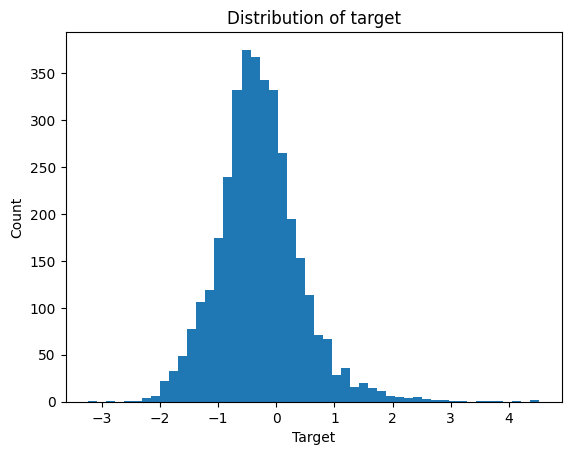

In [88]:
plt.hist(y_train, bins=50)
plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Distribution of target")
plt.show()

As we see above, there are two groups of outliers, one to the right and one to the left. (I changed the above code to remove the positive outliers after I wrote this).

In [42]:
y_train.sort_values(ascending=False).head(50)

word
nanami          4.519630
destiny3        4.408635
jacob           3.729439
vash            3.476375
deltarune       3.450379
charmander      3.262120
jardon          2.873386
boycott         2.760161
cage            2.723162
xenoblade       2.597787
dragonwilds     2.578816
pooh            2.575041
srl             2.473580
kuromi          2.438960
ash             2.436449
kh              2.360179
phasmophobia    2.337473
tekken          2.273856
lankybox        2.218760
necrit          2.186807
giveaway        2.183281
eternia         2.175366
november        2.153305
nolan           2.136376
studdy          2.060779
wewantd3        2.059795
gym             2.057393
pabro           2.048515
caedrel         2.047862
all's           2.018657
gta5            2.010228
imposter        2.008341
omni            1.988313
n64             1.973064
cubes           1.944044
holland         1.925908
sabotaged       1.910899
dmc             1.896566
relink          1.895828
irelia          1.88

Below I check the past average relative frequency and the future average relative frequency for values in large outliers. It looks like they likely are all the ones which have a past average relative frequency of 0, meaning they were used 0 times in the past weeks (we removed all words which did not appear at least 5 times in at least 1 week, but that included future weeks). These outliers should be removed from the dataset.

In [38]:
print(wide.loc['alpharad'][past_rel_cols].mean())
print(wide.loc['alpharad'][future_rel_cols].mean())

3.1437939934671963e-06
0.0016594569778036403


In [39]:
print(wide.loc['lucan'][past_rel_cols].mean())
print(wide.loc['lucan'][future_rel_cols].mean())

6.2875879869343925e-06
0.0012842740640852757


In [40]:
print(wide.loc['sjur'][past_rel_cols].mean())
print(wide.loc['sjur'][future_rel_cols].mean())

0.0
6.0340562132676834e-05


In [41]:
print(wide.loc['sledgehammers'][past_rel_cols].mean())
print(wide.loc['sledgehammers'][future_rel_cols].mean())

0.0
6.0340562132676834e-05


In [42]:
print(wide.loc['adef'][past_rel_cols].mean())
print(wide.loc['adef'][future_rel_cols].mean())

0.0
0.0009343463984402872


In [31]:
y.sort_values(ascending=True).head(1790)

word
manhunt     -16.230565
jamal       -16.100479
drm         -15.733234
lear        -15.498385
drone       -15.424546
               ...    
goff        -11.415895
kellen      -11.415895
raji        -11.415895
bluepoint    -4.275009
predators    -3.846697
Length: 1790, dtype: float64

Below I do the same check for the negative outliers. It appears that they are all the ones which have a future relative frequency of 0, so it was used 0 times in the 3 future weeks. This is a much larger set, containing a little under 1800 words, while the set of positive outliers contained a little under 50 words. We could remove them, although I'm a little unsure here, since in a real life scenario you would not know if the future relative frequency would be 0 or not. The distribution of these outliers in the histogram looks somewhat like a normal distribution, reflecting the distribution of past relative frequencies.

In [43]:
print(wide.loc['raji'][past_rel_cols].mean())
print(wide.loc['raji'][future_rel_cols].mean())

9.075184271616634e-06
0.0


In [44]:
print(wide.loc['kellen'][past_rel_cols].mean())
print(wide.loc['kellen'][future_rel_cols].mean())

9.075184271616634e-06
0.0


In [45]:
print(wide.loc['bluepoint'][past_rel_cols].mean())
print(wide.loc['bluepoint'][future_rel_cols].mean())

0.0008674727481629335
1.2068112426535365e-05


In [46]:
print(wide.loc['predators'][past_rel_cols].mean())
print(wide.loc['predators'][future_rel_cols].mean())

0.0005652521642081516
1.2068112426535365e-05


In [47]:
print(wide.loc['manhunt'][past_rel_cols].mean())
print(wide.loc['manhunt'][future_rel_cols].mean())

0.0011190374730180202
0.0


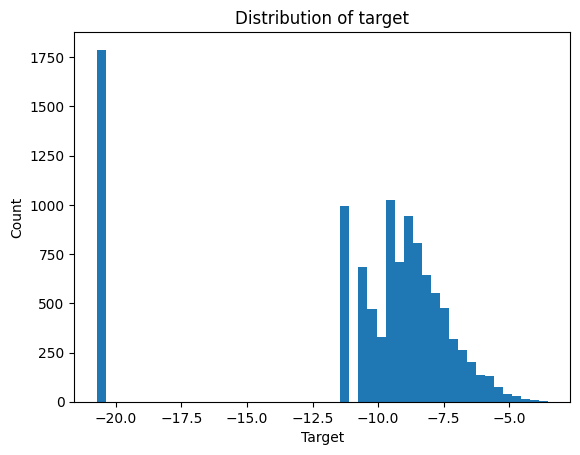

In [82]:
plt.hist(np.log(future_avg + eps_rel), bins=50)
plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Distribution of target")
plt.show()

In [1]:
plt.hist(np.log((future_avg+10e-6) / (past_avg+10e-6)), bins=50)
plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Distribution of target")
plt.show()

NameError: name 'plt' is not defined

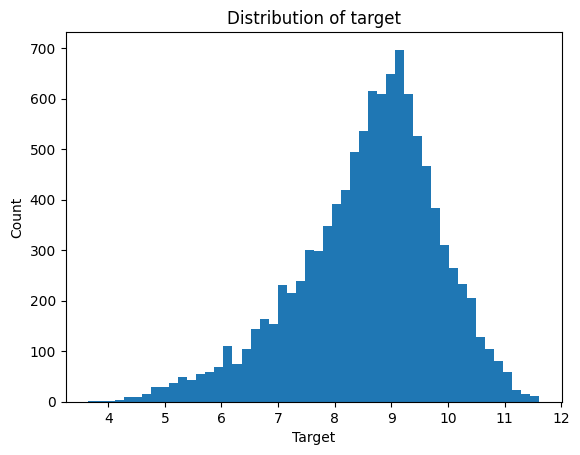

In [84]:
plt.hist(-np.log(past_avg), bins=50)
plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Distribution of target")
plt.show()

In [11]:
y_train_class = y_train.map(lambda y: 1 if y>1 else 0)
y_test_class = y_test.map(lambda y: 1 if y>1 else 0)

In [12]:
len(y_train_class[y_train_class==1])

151

In [13]:
len(y_train_class[y_train_class==0])

3458

In [15]:
#def spearman_score(y_true, y_pred):
#    return spearmanr(y_true, y_pred).statistic

#def pearson_score(y_true, y_pred):
#    return pearsonr(y_true, y_pred)[0]

#cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "logistic": make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty=None)
    ),

    "ridge": make_pipeline(
        StandardScaler(),
        RidgeClassifier(alpha=1.0)
    ),

    "lasso": make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty='l1',solver='liblinear')
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=7,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),

    "extra_trees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),

    "hist_gradient_boosting": HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.05,
        max_leaf_nodes=25,
        random_state=42
    ),

    "xgboost": XGBClassifier(
        objective="reg:squarederror",
        n_estimators=100,
        max_depth=1,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=0,
        reg_alpha=1,
        random_state=42,
        n_jobs=-1
    ),

#    "mlp_small": make_pipeline(
#        StandardScaler(),
#        MLPClassifier(
#            hidden_layer_sizes=(128, 64),
#            activation="relu",
#            alpha=1e-4,
#            learning_rate_init=1e-3,
#            batch_size=128,
#            max_iter=500,
#            early_stopping=True,
#            validation_fraction=0.15,
#            random_state=42
#        )
#    ),

#    "mlp_large": make_pipeline(
#        StandardScaler(),
#        MLPClassifier(
#            hidden_layer_sizes=(256, 128, 64),
#            activation="relu",
#            alpha=1e-4,
#            learning_rate_init=5e-4,
#            batch_size=128,
#            max_iter=600,
#            early_stopping=True,
#            validation_fraction=0.15,
#            random_state=42
#        )
#    ),
#}

for name, model in models.items():

    print(f"Training {name}...")

    #scores = cross_validate(
    #    model,
    #    X,
    #    y,
    #    cv=cv,
    #    scoring=scoring,
    #    n_jobs=-1,
    #    return_train_score=True
    #)
    y_pred = cross_val_predict(
        model,
        X_train,
        y_train_class,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1
    )
    print(confusion_matrix(y_train_class,y_pred))



Training logistic...
[[3374   84]
 [ 112   39]]
Training ridge...
[[3436   22]
 [ 123   28]]
Training lasso...
[[3415   43]
 [ 114   37]]
Training random_forest...
[[3446   12]
 [ 126   25]]
Training extra_trees...
[[3451    7]
 [ 128   23]]
Training hist_gradient_boosting...
[[3439   19]
 [ 117   34]]
Training xgboost...
[[3433   25]
 [ 122   29]]
Training mlp_small...
[[3446   12]
 [ 136   15]]
Training mlp_large...
[[3452    6]
 [ 138   13]]


In [46]:
# current best model
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

#model =  XGBRegressor(
#        objective="reg:squarederror",
#        n_estimators=600,
#        max_depth=5,
#        learning_rate=0.03,
#        subsample=0.8,
#        colsample_bytree=0.8,
#        reg_lambda=1.0,
#        reg_alpha=0.0,
#        random_state=42,
#        n_jobs=-1
#    )

#model = ExtraTreesRegressor(
#        n_estimators=500,
#        max_depth=None,
#        min_samples_leaf=2,
#        random_state=42,
#        n_jobs=-1
#    )

# out-of-fold predictions
y_pred = cross_val_predict(
    model,
    X,
    y,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

eval_df = pd.DataFrame({
    "word": X.index,
    "y_true": y,
    "y_pred": y_pred
}).reset_index(drop=True)

# sanity-check metrics
print("RMSE:", mean_squared_error(eval_df["y_true"], eval_df["y_pred"]) ** 0.5)
print("MAE:", mean_absolute_error(eval_df["y_true"], eval_df["y_pred"]))
print("R2:", r2_score(eval_df["y_true"], eval_df["y_pred"]))
print("Spearman:", spearmanr(eval_df["y_true"], eval_df["y_pred"]).statistic)
print("Pearson:", pearsonr(eval_df["y_true"], eval_df["y_pred"])[0])


RMSE: 1.3222537406412187
MAE: 0.9611860896891673
R2: 0.26858340431948036
Spearman: 0.4539955542950185
Pearson: 0.518378975530802


In [47]:
def ranking_eval(df, k):
    top_pred = df.sort_values("y_pred", ascending=False).head(k)
    top_true = df.sort_values("y_true", ascending=False).head(k)

    top_true_words = set(top_true["word"])
    precision_at_k = top_pred["word"].isin(top_true_words).mean()

    return {
        "k": k,
        "overlap_count": int(top_pred["word"].isin(top_true_words).sum()),
        "precision_at_k": precision_at_k,
        "avg_true_y_pred_topk": top_pred["y_true"].mean(),
        "avg_true_y_ideal_topk": top_true["y_true"].mean(),
        "median_true_y_pred_topk": top_pred["y_true"].median(),
        "median_true_y_ideal_topk": top_true["y_true"].median(),
    }

ranking_results = pd.DataFrame([
    ranking_eval(eval_df, k)
    for k in [10, 20, 50, 100, 200]
])

ranking_results


,k,overlap_count,precision_at_k,avg_true_y_pred_topk,avg_true_y_ideal_topk,median_true_y_pred_topk,median_true_y_ideal_topk
0,10,0,0.000,0.456393,3.627913,0.478723,3.571145
1,20,0,0.000,0.340850,3.125390,0.381881,2.836597
2,50,0,0.000,0.258149,2.525752,0.291501,2.306636
3,100,0,0.000,0.156050,2.135404,0.252393,1.892584
4,200,3,0.015,0.074871,1.764754,0.133873,1.608263


In [48]:
eval_df.sort_values("y_pred", ascending=False).head(50)


,word,y_true,y_pred
2302,d3,1.112279,0.357599
4003,gods,-0.265121,0.302691
2372,dawn,-0.157976,0.217774
7327,ps2,0.475871,0.210293
4172,guardians,1.171314,0.194733
6995,playstation,0.447451,0.189856
9555,titans,0.562555,0.188539
800,banger,0.481575,0.185263
4584,hype,0.488224,0.173852
6165,multiplayer,0.247756,0.166553


In [49]:
eval_df.sort_values("y_true", ascending=False).head(50)


,word,y_true,y_pred
6232,nanami,4.453785,-0.541620
2551,destiny3,4.328115,-0.781537
9731,trine,4.115112,-2.398642
5516,locke,3.803210,-1.284081
4915,jacob,3.700380,-1.377986
2475,deltarune,3.441909,-1.128868
10044,vash,3.416393,-0.560648
1591,charmander,3.229278,-2.144379
8911,stampede,2.949127,-0.707122
4942,jardon,2.841824,-2.825457


In [38]:
X.iloc[1481]

week_0_count            2.000000
week_1_count            1.000000
week_2_count            1.000000
week_3_count            2.000000
week_4_count           12.000000
                        ...     
likes_prev3_mean     5310.666667
likes_momentum_3w   -4644.000000
rel_freq_slope          0.000005
count_slope             0.134804
likes_slope          -350.112745
Name: cardboard, Length: 269, dtype: float64

In [16]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

feature_importance.head(20)

,feature,importance
258,n_videos_mean,0.278632
251,count_max,0.172835
260,rel_freq_recent3_mean,0.056127
67,week_16_n_videos,0.018642
248,weeks_nonzero,0.016146
252,rel_freq_mean,0.011042
253,rel_freq_std,0.010811
250,count_std,0.008541
268,likes_slope,0.008011
254,rel_freq_max,0.007966


In [17]:
corr = X.corrwith(y).sort_values(key=abs, ascending=False)
corr.head(20)

weeks_nonzero         0.429092
week_16_n_channels    0.293767
week_15_n_channels    0.272077
week_10_n_channels    0.271377
week_13_n_channels    0.264661
week_11_n_channels    0.263548
week_3_n_channels     0.262868
week_14_n_channels    0.261363
week_12_n_channels    0.260469
week_7_n_channels     0.260267
week_5_n_channels     0.259602
week_6_n_channels     0.259406
week_9_n_channels     0.259186
week_8_n_channels     0.256427
week_2_n_channels     0.254444
week_4_n_channels     0.253353
week_1_n_channels     0.251762
week_0_n_channels     0.247057
week_16_n_videos      0.176099
n_videos_max          0.175514
dtype: float64

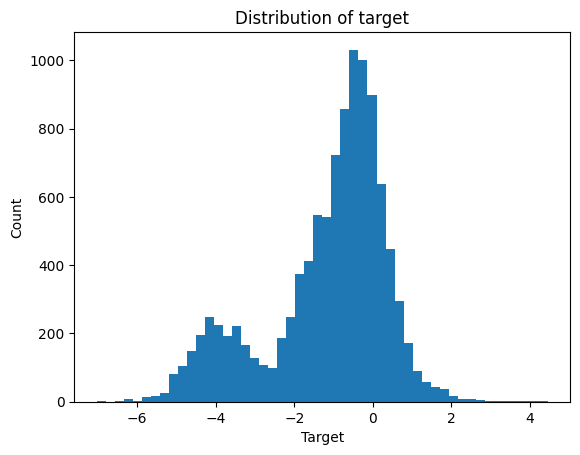

In [50]:
plt.hist(y, bins=50)
plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Distribution of target")
plt.show()

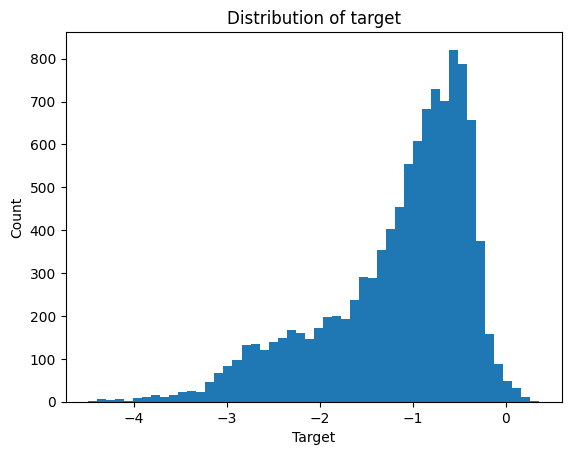

In [51]:
plt.hist(y_pred, bins=50)
plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Distribution of target")
plt.show()

<Axes: >

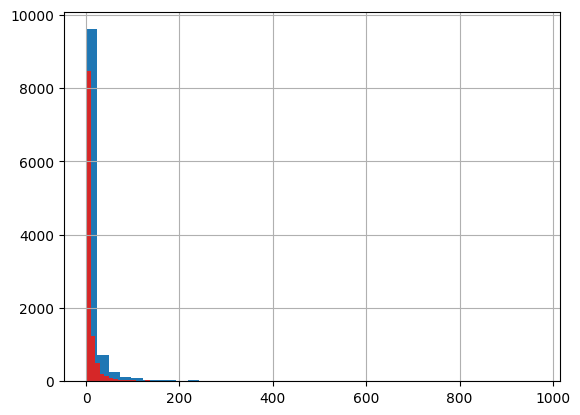

In [19]:
X["week_16_count"].hist(bins=40)
X["week_16_rel_freq"].hist(bins=40)
X["week_16_n_channels"].hist(bins=40)
X["week_16_n_videos"].hist(bins=40)

Text(0, 0.5, 'Target')

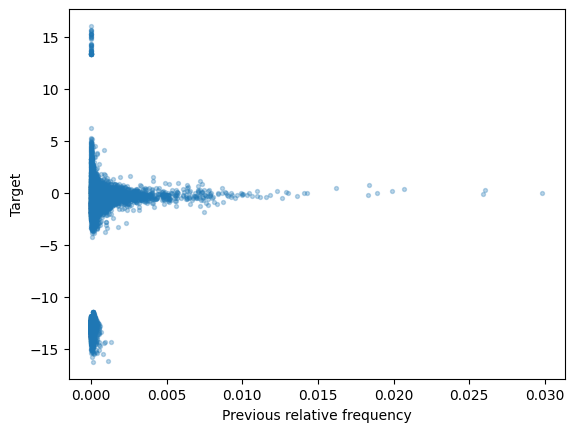

In [20]:
plt.scatter(
    X["week_16_rel_freq"],
    y,
    s=8,
    alpha=0.3
)
plt.xlabel("Previous relative frequency")
plt.ylabel("Target")

In [21]:
X.isna().sum().sort_values(ascending=False).head(20)

week_0_count     0
week_1_count     0
week_2_count     0
week_3_count     0
week_4_count     0
week_5_count     0
week_6_count     0
week_7_count     0
week_8_count     0
week_9_count     0
week_10_count    0
week_11_count    0
week_12_count    0
week_13_count    0
week_14_count    0
week_15_count    0
week_16_count    0
week_0_likes     0
week_1_likes     0
week_2_likes     0
dtype: int64

In [22]:
top_words = eval_df.nlargest(100, "y_true")["word"]

X_top = X.loc[top_words]
X_rest = X.drop(top_words)

top_means = X_top.mean()
rest_means = X_rest.mean()

comparison = pd.DataFrame({
    "top100_mean": top_means,
    "rest_mean": rest_means,
    "difference": top_means - rest_means,
    "ratio": top_means / (rest_means + 1e-10)
}).sort_values("difference", ascending=False)

comparison.head(30)

,top100_mean,rest_mean,difference,ratio
rel_likes_log_growth_8_7,0.340786,-0.694385,1.035171,-0.490774
rel_freq_log_growth_10_9,1.080166,0.111246,0.968920,9.709670
rel_freq_log_growth_16_15,1.506794,0.564964,0.941830,2.667062
rel_likes_log_growth_5_4,0.365841,-0.388218,0.754059,-0.942360
rel_freq_log_growth_8_7,0.255931,-0.469134,0.725065,-0.545540
rel_freq_log_growth_5_4,0.509324,-0.049843,0.559167,-10.218651
rel_likes_log_growth_10_9,0.834409,0.277942,0.556468,3.002104
rel_freq_log_growth_14_13,0.393794,-0.062589,0.456383,-6.291726
likes_log_growth_8_7,0.125928,-0.295826,0.421754,-0.425681
rel_likes_log_growth_14_13,0.433861,0.059840,0.374021,7.250384


In [23]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf,
    X,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)


In [24]:
perm.head(20)

,feature,importance
258,n_videos_mean,0.573866
251,count_max,0.253428
260,rel_freq_recent3_mean,0.115176
67,week_16_n_videos,0.085983
248,weeks_nonzero,0.031462
101,week_16_rel_freq,0.013666
267,count_slope,0.013235
16,week_16_count,0.011752
268,likes_slope,0.011307
253,rel_freq_std,0.011233


For the sake of argument, say "viral" means y>2

In [21]:
timey_class = timey.map(lambda y: 1 if y>1 else 0)

In [27]:
model = RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
y_pred = cross_val_predict(
    model,
    timeX,
    timey_class,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

print(confusion_matrix(timey_class,y_pred))

[[127468    233]
 [  3494    496]]


For a dummy regression, we will calculate a predicted y value by taking log of (average relative frequency at time 0,-1,-2+eps)/(average relative freqeuncy at time -3,...,-9)

In [134]:
dummy_pred = pd.Series(index = timeX.index)
for i in currentweeks:
    # Target y
    # X uses feature_weeks
    # y uses future_weeks
    past_rel_cols = [f"week_{i}_rel_freq" for i in range(i-9,i+-2)]
    future_rel_cols = [f"week_{i}_rel_freq" for i in range(i-2,i+1)]

    past_avg = wide[past_rel_cols].mean(axis=1)
    future_avg = wide[future_rel_cols].mean(axis=1)

    dummy_pred.loc[i] = np.log((future_avg + eps_rel) / (past_avg + eps_rel))
    
dummy_pred_time = dummy_pred.loc[timey_val_time.index]
dummy_pred_words = dummy_pred.loc[timey_val_words.index]
dummy_pred_time_class = dummy_pred_time.map(lambda y: 1 if y>1 else 0)
dummy_pred_words_class = dummy_pred_words.map(lambda y: 1 if y>1 else 0)

conf_time = confusion_matrix(timey_val_time,dummy_pred_time_class)
conf_words = confusion_matrix(timey_val_words,dummy_pred_words_class)

print("Training dummy...")
print(conf_time)
print("precision: "+str(conf_time[1,1]/(conf_time[1,1]+conf_time[0,1])))
print("recall: "+str(conf_time[1,1]/(conf_time[1,1]+conf_time[1,0])))
print("New words confusion matrix")
print(conf_words)
print("precision: "+str(conf_words[1,1]/(conf_words[1,1]+conf_words[0,1])))
print("recall: "+str(conf_words[1,1]/(conf_words[1,1]+conf_words[1,0])))

Training dummy...
[[15500   456]
 [  378   145]]
precision: 0.24126455906821964
recall: 0.27724665391969405
New words confusion matrix
[[15649   551]
 [  407   132]]
precision: 0.19326500732064422
recall: 0.24489795918367346


In [131]:
models = {
    "logistic": make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty=None)
    ),

    "ridge": make_pipeline(
        StandardScaler(),
        RidgeClassifier(alpha=1.0)
    ),

    "lasso": make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty='l1',solver='liblinear')
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=7,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),

    "extra_trees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),

    "hist_gradient_boosting": HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.05,
        max_leaf_nodes=25,
        random_state=42
    ),

    "xgboost": XGBClassifier(
        objective="reg:squarederror",
        n_estimators=100,
        max_depth=1,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=0,
        reg_alpha=1,
        random_state=42,
        n_jobs=-1
    )
}

#    "mlp_small": make_pipeline(
#        StandardScaler(),
#        MLPClassifier(
#            hidden_layer_sizes=(128, 64),
#            activation="relu",
#            alpha=1e-4,
#            learning_rate_init=1e-3,
#            batch_size=128,
#            max_iter=500,
#            early_stopping=True,
#            validation_fraction=0.15,
#            random_state=42
#        )
#    ),

#    "mlp_large": make_pipeline(
#        StandardScaler(),
#        MLPClassifier(
#            hidden_layer_sizes=(256, 128, 64),
#            activation="relu",
#            alpha=1e-4,
#            learning_rate_init=5e-4,
#            batch_size=128,
#            max_iter=600,
#            early_stopping=True,
#            validation_fraction=0.15,
#            random_state=42
#        )
#    ),
#}


rows = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(timeX_tt,timey_tt)
    y_pred_time = model.predict(timeX_val_time)
    y_pred_words = model.predict(timeX_val_words)
    conf_time = confusion_matrix(timey_val_time,y_pred_time)
    conf_words = confusion_matrix(timey_val_words,y_pred_words)
    print("New time confusion matrix")
    print(confusion_matrix(timey_val_time,y_pred_time))
    print("precision: "+str(conf_time[1,1]/(conf_time[1,1]+conf_time[0,1])))
    print("recall: "+str(conf_time[1,1]/(conf_time[1,1]+conf_time[1,0])))
    print("New words confusion matrix")
    print(confusion_matrix(timey_val_words,y_pred_words))
    print("precision: "+str(conf_words[1,1]/(conf_words[1,1]+conf_words[0,1])))
    print("recall: "+str(conf_words[1,1]/(conf_words[1,1]+conf_words[1,0])))

Training logistic...
New time confusion matrix
[[15924    32]
 [  472    51]]
precision: 0.6144578313253012
recall: 0.09751434034416825
New words confusion matrix
[[16146    54]
 [  480    59]]
precision: 0.5221238938053098
recall: 0.10946196660482375
Training ridge...
New time confusion matrix
[[15952     4]
 [  516     7]]
precision: 0.6363636363636364
recall: 0.01338432122370937
New words confusion matrix
[[16195     5]
 [  533     6]]
precision: 0.5454545454545454
recall: 0.011131725417439703
Training lasso...
New time confusion matrix
[[15924    32]
 [  472    51]]
precision: 0.6144578313253012
recall: 0.09751434034416825
New words confusion matrix
[[16145    55]
 [  473    66]]
precision: 0.5454545454545454
recall: 0.12244897959183673
Training random_forest...
New time confusion matrix
[[15925    31]
 [  454    69]]
precision: 0.69
recall: 0.13193116634799235
New words confusion matrix
[[16165    35]
 [  466    73]]
precision: 0.6759259259259259
recall: 0.13543599257884972
Traini

Looking at the results, it looks like xgboost is the best. It is interesting to note that the recall of the dummy predictor appears to be better than the recall of any of the other models, but its precision is way worse, which we care about more. The dummy predictor just predicts more of the words to be viral than other models do.

In [135]:
# training final model
xgboost = XGBClassifier(
        objective="reg:squarederror",
        n_estimators=100,
        max_depth=1,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=0,
        reg_alpha=1,
        random_state=42,
        n_jobs=-1
    )
xgboost.fit(timeX_train,timey_train)
y_pred_time = model.predict(timeX_test_time)
y_pred_words = model.predict(timeX_test_words)
conf_time = confusion_matrix(timey_test_time,y_pred_time)
conf_words = confusion_matrix(timey_test_words,y_pred_words)
print("New time confusion matrix")
print(conf_time)
print("precision: "+str(conf_time[1,1]/(conf_time[1,1]+conf_time[0,1])))
print("recall: "+str(conf_time[1,1]/(conf_time[1,1]+conf_time[1,0])))
print("New words confusion matrix")
print(conf_words)
print("precision: "+str(conf_words[1,1]/(conf_words[1,1]+conf_words[0,1])))
print("recall: "+str(conf_words[1,1]/(conf_words[1,1]+conf_words[1,0])))

New time confusion matrix
[[20600    82]
 [  500    97]]
precision: 0.5418994413407822
recall: 0.1624790619765494
New words confusion matrix
[[25156    65]
 [  675   117]]
precision: 0.6428571428571429
recall: 0.14772727272727273


Unfortunately the results are worse than they were for the validation sets. It's possible this is due in part to how less comments were scraped in the final weeks (this is especially important for the time confusion matrix). It still works much better than the dummy predictor.

In [152]:
timey_test_time.loc[timey_test_time.map(lambda y: y==1)].index

MultiIndex([(32,        '200k'),
            (32,         '9th'),
            (32, 'accusations'),
            (32,      'amiibo'),
            (32,       'asian'),
            (32,   'backrooms'),
            (32,       'bambu'),
            (32,         'ben'),
            (32,        'bond'),
            (32,    'broccoli'),
            ...
            (36,       'vayne'),
            (36,     'vibrant'),
            (36,        'vice'),
            (36,         'vii'),
            (36,     'warbond'),
            (36,      'wicked'),
            (36,         'wii'),
            (36,     'wishing'),
            (36,   'xenoblade'),
            (36,       'zelda')],
           names=[None, 'word'], length=597)

In [158]:
timey_test_time.loc[y_pred_time==1].index

MultiIndex([(32,       'bambu'),
            (32,         'bmw'),
            (32, 'cindercrest'),
            (32,     'eclipse'),
            (32,        'ford'),
            (32,       'gally'),
            (32,  'hantavirus'),
            (32,     'insider'),
            (32,         'jew'),
            (32,    'mercedes'),
            ...
            (36,  'revelation'),
            (36,       'senua'),
            (36,      'shinji'),
            (36,    'stampede'),
            (36,    'starside'),
            (36,    'telltale'),
            (36,        'vash'),
            (36,     'vibrant'),
            (36,         'vii'),
            (36,        'xeno')],
           names=[None, 'word'], length=179)

In [160]:
timey_test_time.loc[(y_pred_time==1)&timey_test_time.map(lambda y: y==1)].index

MultiIndex([(32,          'bambu'),
            (32,    'cindercrest'),
            (32,           'ford'),
            (32,          'gally'),
            (32,     'hantavirus'),
            (32,        'insider'),
            (32,            'jew'),
            (32,     'millennial'),
            (32,         'mmorpg'),
            (32,         'mw2019'),
            (32,        'painter'),
            (32,           'reno'),
            (32,            'tmz'),
            (32,         'tyler1'),
            (32,        'warmind'),
            (32,           'zhao'),
            (33,        'airflow'),
            (33,          'clark'),
            (33,          'croft'),
            (33,      'daredevil'),
            (33,          'diver'),
            (33,           'dune'),
            (33,           'jean'),
            (33,            'lao'),
            (33,           'mw19'),
            (33,         'mw2019'),
            (33,        'parsons'),
            (33,      'telep

In [150]:
timey_test_words.loc[timey_test_time.map(lambda y: y==1)].index

MultiIndex([( 9,      'ashes'),
            ( 9,  'australia'),
            ( 9,      'bitte'),
            ( 9,    'bluesky'),
            ( 9,     'client'),
            ( 9,    'concord'),
            ( 9,   'december'),
            ( 9,     'diablo'),
            ( 9,      'elden'),
            ( 9, 'hd-version'),
            ...
            (36,       'luck'),
            (36,        'min'),
            (36,     'mutant'),
            (36,        'n64'),
            (36,    'shadows'),
            (36,      'stamp'),
            (36,        'tem'),
            (36,     'thragg'),
            (36,     'vandal'),
            (36,       'york')],
           names=[None, 'word'], length=792)

In [159]:
timey_test_words.loc[y_pred_words==1].index

MultiIndex([( 9, 'hd-version'),
            (10,   'maturing'),
            (11, 'enderpearl'),
            (11,     'shroom'),
            (12, 'enderpearl'),
            (12,      'fleet'),
            (12,        'gdp'),
            (12,     'redact'),
            (12,     'shroom'),
            (12,      'tungs'),
            ...
            (35, 'lieutenant'),
            (35,       'loki'),
            (35, 'nightreign'),
            (35,     'persia'),
            (35, 'stronghold'),
            (35,  'traveller'),
            (36,       'dept'),
            (36,    'envidia'),
            (36,  'hellblade'),
            (36, 'nightreign')],
           names=[None, 'word'], length=182)

In [161]:
timey_test_words.loc[(y_pred_words==1)&timey_test_words.map(lambda y: y==1)].index

MultiIndex([( 9,      'hd-version'),
            (10,        'maturing'),
            (11,          'shroom'),
            (12,             'gdp'),
            (12,          'redact'),
            (12,          'shroom'),
            (12,           'tungs'),
            (13, 'captainsparklez'),
            (13,          'shroom'),
            (13,           'tungs'),
            ...
            (33,           'fleek'),
            (33,             'gt7'),
            (34,        'octopath'),
            (34,       'traveller'),
            (35,         'adamson'),
            (35,       'barricade'),
            (35,      'lieutenant'),
            (35,          'persia'),
            (35,      'stronghold'),
            (36,       'hellblade')],
           names=[None, 'word'], length=117)